# Final analysis
## What to do?
- Answer the questions of exploratory analysis
- Focus on making good visualization
- Make a report of what we found and what answer we got for it
## What to take care of?
- if there is a question that need to be answered but the exploratory analysis haven't covered it, we will cover it here
- Everything should have a visualization of it

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

### We will not write more code unless it is not present in the **03_exploratory analysis**, so please do consider going through 03_exploratory_analysis first. This file goal is to only present a `report of what we found`.......

In [2]:
# setting maximum columns
pd.set_option('display.max_columns', 100)

In [3]:
# lets import the filtered data that we made in 02_data_cleaning.ipynb
df60 = pd.read_csv('../Data/Filtered/ucr_1960_cleaned.csv') # 1960 data
df61 = pd.read_csv('../Data/Filtered/ucr_1961_cleaned.csv') # 1961 data
df62 = pd.read_csv('../Data/Filtered/ucr_1962_cleaned.csv') # 1962 data
df = pd.read_csv('../Data/Filtered/ucr_1960_1962_cleaned.csv') # 1960-1962 data

### 1. **`Data Information`**

In [4]:
# Total no. of entries
print(f'Year 1960 has {df60.shape[0]} distinct entries')
print()
print(f'Year 1961 has {df61.shape[0]} distinct entries')
print()
print(f'Year 1962 has {df62.shape[0]} distinct entries')

Year 1960 has 20558 distinct entries

Year 1961 has 23232 distinct entries

Year 1962 has 24696 distinct entries


In [5]:
# Total no. of Data Fields
print(f'Year 1960 has {df60.shape[1]} Non-Zero distinct fields')
print()
print(f'Year 1961 has {df61.shape[1]} Non-Zero distinct fields')
print()
print(f'Year 1962 has {df62.shape[1]} Non-Zero distinct fields')

Year 1960 has 53 Non-Zero distinct fields

Year 1961 has 53 Non-Zero distinct fields

Year 1962 has 53 Non-Zero distinct fields


In [6]:
# Total no. of fields with either Zero or NaN values are:-
print(f'Year 1960 has 19 Zero or NaN distinct fields')
print()
print(f'Year 1961 has 19 Zero or NaN distinct fields')
print()
print(f'Year 1962 has 19 Zero or NaN distinct fields')
# Please refer to data inspection to know the details

Year 1960 has 19 Zero or NaN distinct fields

Year 1961 has 19 Zero or NaN distinct fields

Year 1962 has 19 Zero or NaN distinct fields


In [7]:
# Total no. of reporting agencies in each year:
print(f'Year 1960 has {df60.ORI.nunique()} total distinct agencies')
print()
print(f'Year 1961 has {df61.ORI.nunique()} total distinct agencies')
print()
print(f'Year 1962 has {df62.ORI.nunique()} total distinct agencies')

Year 1960 has 1317 total distinct agencies

Year 1961 has 1554 total distinct agencies

Year 1962 has 1664 total distinct agencies


In [8]:
# Total no. of distinct crime codes:-
print(f'Year 1960 has {df60.OFF.nunique()} total distinct crime codes')
print()
print(f'Year 1961 has {df61.OFF.nunique()} total distinct crime codes')
print()
print(f'Year 1962 has {df62.OFF.nunique()} total distinct crime codes')

Year 1960 has 25 total distinct crime codes

Year 1961 has 25 total distinct crime codes

Year 1962 has 25 total distinct crime codes


In [9]:
# Total no. of different states
print(f'Year 1960 has {df60.ST.nunique()} Different States(ST)')
print()
print(f'Year 1961 has {df61.ST.nunique()} Different States(ST)')
print()
print(f'Year 1962 has {df62.ST.nunique()} Different States(ST)')

Year 1960 has 47 Different States(ST)

Year 1961 has 47 Different States(ST)

Year 1962 has 47 Different States(ST)


In [10]:
# Total no. of Different Divisions
print(f'Year 1960 has {df60.DIV.nunique()} Different Divisions(DIV)')
print()
print(f'Year 1961 has {df61.DIV.nunique()} Different Divisions(DIV)')
print()
print(f'Year 1962 has {df62.DIV.nunique()} Different Divisions(DIV)')

Year 1960 has 10 Different Divisions(DIV)

Year 1961 has 9 Different Divisions(DIV)

Year 1962 has 9 Different Divisions(DIV)


In [11]:
# Total No of arrests per year:-
# Initiating loop
for f in (df60,df61,df62):
    AGE_M = [f'M{i}' for i in range(3, 25) if i not in (7, 21, 22, 23)]   # M3..M24
    AGE_F = [f'F{i}' for i in range(3, 25) if i not in (7, 21, 22, 23)]   # F3..F24
    f['total_male']    = f[AGE_M].sum(axis=1)
    f['total_female']  = f[AGE_F].sum(axis=1)
    f['total_arrests'] = f['total_male'] + f['total_female']

print(f'Year 1960 has {df60.total_arrests.sum()} Total Arrests(total_arrests)')
print()
print(f'Year 1961 has {df61.total_arrests.sum()} Total Arrests(total_arrests)')
print()
print(f'Year 1962 has {df62.total_arrests.sum()} Total Arrests(total_arrests)')

Year 1960 has 3387736 Total Arrests(total_arrests)

Year 1961 has 3382630 Total Arrests(total_arrests)

Year 1962 has 3606365 Total Arrests(total_arrests)


#### This leads to our first question
**Question**:- `Did arrests per reporting agency change from 1960 to 1962? Did the composition of arrests shift, rather than the absolute count?`

In [12]:
#Initiating loop for arrests by agency
rows = []
for f in (df60, df61, df62):
    rows.append({
        'YEAR': f['YEAR'].iloc[0],
        'agencies': f['ORI'].nunique(),
        'total': f['total_arrests'].sum(),
    })
by_year = pd.DataFrame(rows).set_index('YEAR')
by_year['per_agency'] = by_year['total'] / by_year['agencies']
print(by_year)

      agencies    total   per_agency
YEAR                                
1960      1317  3387736  2572.312832
1961      1554  3382630  2176.724582
1962      1664  3606365  2167.286659


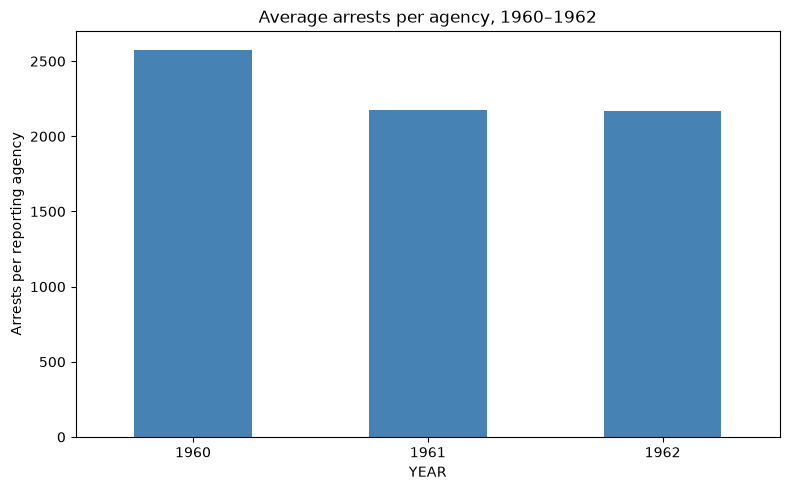

In [13]:
fig, ax = plt.subplots(figsize=(8, 5))
by_year['per_agency'].plot(kind='bar', ax=ax, color='steelblue')
ax.set_ylabel('Arrests per reporting agency')
ax.set_title('Average arrests per agency, 1960–1962')
ax.set_xticklabels(['1960', '1961', '1962'], rotation=0)
plt.tight_layout()
plt.savefig('../figures/final_per_agency_by_year.png', dpi=150)
plt.show()